<a href="https://colab.research.google.com/github/LucianoMacias/Aplicacion_Nuevas_Tecnologias-Luciano_Macias/blob/main/tp03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Cantidad de registros:", X.shape[0])
print("Cantidad de features:", X.shape[1])

print("\nFeatures:")
print(housing.feature_names)

Cantidad de registros: 20640
Cantidad de features: 8

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

modelo = LinearRegression()

modelo.fit(X_train, y_train)

y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

print("MSE Train:", mean_squared_error(y_train, y_train_pred))
print("MSE Test:", mean_squared_error(y_test, y_test_pred))

print("R2 Train:", r2_score(y_train, y_train_pred))
print("R2 Test:", r2_score(y_test, y_test_pred))

MSE Train: 0.5179331255246699
MSE Test: 0.5558915986952422
R2 Train: 0.6125511913966952
R2 Test: 0.5757877060324524


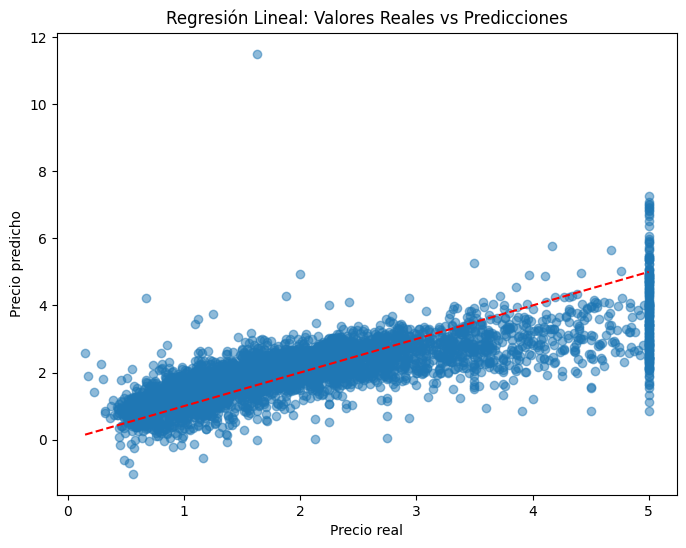

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred, alpha=0.5)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Regresión Lineal: Valores Reales vs Predicciones")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

modelo_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

modelo_poly.fit(X_train, y_train)

y_train_poly = modelo_poly.predict(X_train)
y_test_poly = modelo_poly.predict(X_test)

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

mse_train_poly = mean_squared_error(y_train, y_train_poly)
mse_test_poly = mean_squared_error(y_test, y_test_poly)

r2_train_poly = r2_score(y_train, y_train_poly)
r2_test_poly = r2_score(y_test, y_test_poly)

print("MSE Train:", mse_train_poly)
print("MSE Test:", mse_test_poly)

print("R2 Train:", r2_train_poly)
print("R2 Test:", r2_test_poly)

MSE Train: 0.4207266151573583
MSE Test: 0.4643015261571134
R2 Train: 0.6852681982344935
R2 Test: 0.6456819711504156


In [8]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Feature": housing.feature_names,
    "Coeficiente": modelo.coef_
})

coeficientes["Abs"] = coeficientes["Coeficiente"].abs()

coeficientes.sort_values(
    by="Abs",
    ascending=False
)

,Feature,Coeficiente,Abs
3,AveBedrms,0.783145,0.783145
0,MedInc,0.448675,0.448675
7,Longitude,-0.433708,0.433708
6,Latitude,-0.419792,0.419792
2,AveRooms,-0.123323,0.123323
1,HouseAge,0.009724,0.009724
5,AveOccup,-0.003526,0.003526
4,Population,-0.000002,0.000002


# Respuestas

## ¿Cuál modelo es mejor? ¿Cómo lo determinaron?

El modelo de regresión polinómica de grado 2 obtuvo mejores resultados que la regresión lineal. Esto se determinó comparando las métricas de evaluación. El modelo polinómico presentó valores menores de MSE (0.421 en train y 0.464 en test) y valores mayores de R² (0.685 en train y 0.646 en test). Esto indica que explica una mayor proporción de la variabilidad de los precios y comete menos errores en sus predicciones.

## ¿Hay señales de overfitting en alguno? ¿Cómo se dan cuenta?

No se observan señales fuertes de overfitting en ninguno de los modelos. En ambos casos las métricas obtenidas en entrenamiento y prueba son relativamente similares. Si hubiera overfitting, esperaríamos ver un desempeño mucho mejor en entrenamiento que en prueba. Aunque el modelo polinómico tiene una diferencia ligeramente mayor entre train y test, esta no es lo suficientemente grande como para indicar un sobreajuste importante.

## ¿Qué feature tiene más impacto en el precio? ¿Cómo lo averiguaron?

Para determinar qué característica tiene más impacto se analizaron los coeficientes de la regresión lineal. La variable AveBedrms (promedio de dormitorios por vivienda) presentó el coeficiente absoluto más alto (0.783), por lo que es la que tiene mayor influencia sobre las predicciones del modelo según este análisis. Esto se obtuvo ordenando los coeficientes del modelo por su valor absoluto.